In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Dataset
data = pd.DataFrame({
    "Age": [25, 35, 45, 30, 50, 55],
    "Income": [20, 40, 60, 25, 80, 90],
    "CreditLimit": [30, 60, 90, 35, 120, 150],
    "SpendingScore": [80, 70, 60, 85, 40, 35],
    "Transactions": [120, 100, 80, 130, 60, 50]
})


data



,Age,Income,CreditLimit,SpendingScore,Transactions
0,25,20,30,80,120
1,35,40,60,70,100
2,45,60,90,60,80
3,30,25,35,85,130
4,50,80,120,40,60
5,55,90,150,35,50


In [2]:
# Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_data


array([[-1.38873015, -1.23021658, -1.16006485,  0.97227182,  1.01904933],
       [-0.46291005, -0.47316022, -0.47543641,  0.44194174,  0.33968311],
       [ 0.46291005,  0.28389613,  0.20919202, -0.08838835, -0.33968311],
       [-0.9258201 , -1.04095249, -1.04596011,  1.23743687,  1.35873244],
       [ 0.9258201 ,  1.04095249,  0.89382046, -1.14904852, -1.01904933],
       [ 1.38873015,  1.41948067,  1.57844889, -1.41421356, -1.35873244]])

In [3]:
# PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
pca_data



array([[-2.58046966, -0.33259231],
       [-0.98092038, -0.06787176],
       [ 0.61862889,  0.19684879],
       [-2.50826345,  0.32210751],
       [ 2.24886727, -0.14766101],
       [ 3.20215734,  0.02916878]])

In [4]:
 # Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.98687771 0.00934605]


In [5]:
# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=data.columns
)
print(loadings)


                    PC1       PC2
Age            0.445013  0.677681
Income         0.449621  0.176749
CreditLimit    0.448463  0.129908
SpendingScore -0.446307  0.557247
Transactions  -0.446648  0.426741


Create PCA Scores DataFrame

In [6]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)
print(pca_df)


        PC1       PC2
0 -2.580470 -0.332592
1 -0.980920 -0.067872
2  0.618629  0.196849
3 -2.508263  0.322108
4  2.248867 -0.147661
5  3.202157  0.029169


Visualize PCA (2D Plot) 📊

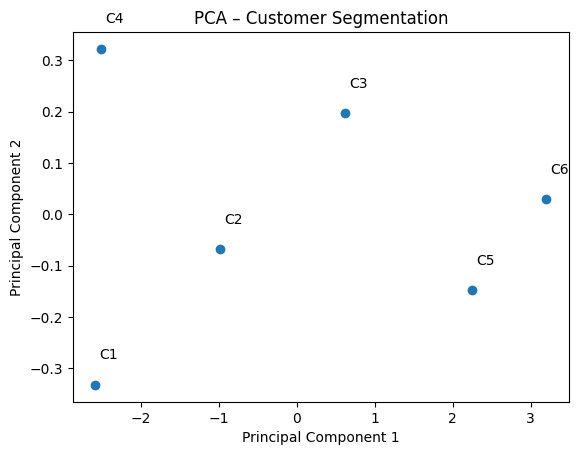

In [7]:
import matplotlib.pyplot as plt

plt.scatter(pca_df["PC1"], pca_df["PC2"])

for i in range(len(pca_df)):
    plt.text(
        pca_df["PC1"][i]+0.05,
        pca_df["PC2"][i]+0.05,
        f"C{i+1}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA – Customer Segmentation")
plt.show()


Check Cumulative Explained Variance

In [8]:
import numpy as np

explained = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative Explained Variance:", explained)


Cumulative Explained Variance: [0.98687771 0.99622376]


Interpretation:

“First 2 components explain 95% of the information”

Use PCA Output for Clustering (Real Use Case)

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
pca_df["Cluster"] = kmeans.fit_predict(pca_df)

print(pca_df)


        PC1       PC2  Cluster
0 -2.580470 -0.332592        0
1 -0.980920 -0.067872        0
2  0.618629  0.196849        0
3 -2.508263  0.322108        0
4  2.248867 -0.147661        1
5  3.202157  0.029169        1


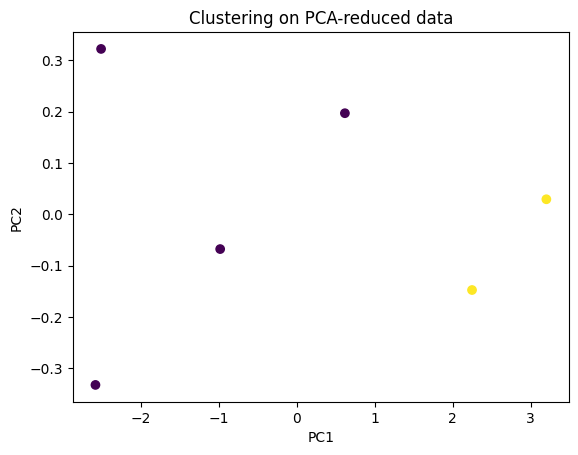

In [10]:
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"]
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering on PCA-reduced data")
plt.show()


Back-Explain Clusters (Business Interpretation)

Example:

🔹 Cluster 0 – High Engagement Customers

High spending

Frequent transactions

Younger to middle age

🔹 Cluster 1 – High Capacity, Low Usage

High income

High credit limit

Low spending & transactions

💡 This is exactly how PCA is used in customer analytics

In [11]:
from sklearn.metrics import silhouette_score
silhoustte_score = silhouette_score(pca_df, pca_df["Cluster"])
print("Silhouette Score:", silhoustte_score)

Silhouette Score: 0.5549299734026055
